In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/cbam-densenet121/pytorch/default/1/densenet121_chunked.pth


In [2]:

# Cross-Dataset Validation: CBAM+DenseNet121 on Camelyon17-WILDS
# Trained on PatchCamelyon (Camelyon16), tested on Camelyon17-WILDS

import os
import time
import random
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from torchvision.models.densenet import _DenseBlock

# Metrics
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score, f1_score,
    classification_report, confusion_matrix, roc_curve, precision_recall_curve
)
from tqdm import tqdm

# Hugging Face datasets
from datasets import load_dataset

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# =============================================================================
# ATTENTION MODULES (CBAM, SE, ECA)
# =============================================================================

class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x).squeeze(3).squeeze(2))
        max_out = self.fc(self.max_pool(x).squeeze(3).squeeze(2))
        out = avg_out + max_out
        return self.sigmoid(out).unsqueeze(2).unsqueeze(3)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.cat([avg_out, max_out], dim=1)
        out = self.conv(out)
        return self.sigmoid(out)

class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        out = x * self.ca(x)
        out = out * self.sa(out)
        return out

class SqueezeExcitation(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SqueezeExcitation, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(channels, channels // reduction, bias=False)
        self.relu = nn.ReLU(inplace=True)
        self.fc2 = nn.Linear(channels // reduction, channels, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).squeeze(-1).squeeze(-1)
        y = self.fc1(y)
        y = self.relu(y)
        y = self.fc2(y)
        y = self.sigmoid(y).unsqueeze(-1).unsqueeze(-1)
        return x * y.expand_as(x)

class ECA(nn.Module):
    def __init__(self, channels, k_size=3):
        super(ECA, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=k_size, padding=(k_size - 1) // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        y = self.avg_pool(x)
        y = self.conv(y.squeeze(-1).transpose(-1, -2)).transpose(-1, -2).unsqueeze(-1)
        y = self.sigmoid(y)
        return x * y.expand_as(x)

In [6]:
# Cross-Dataset Validation: CBAM+DenseNet121 on Camelyon17-WILDS
# Trained on PatchCamelyon (Camelyon16), tested on Camelyon17-WILDS

import os
import time
import random
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from torchvision.models.densenet import _DenseBlock

# Metrics
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score, f1_score,
    classification_report, confusion_matrix, roc_curve, precision_recall_curve
)
from tqdm import tqdm

# Hugging Face datasets
from datasets import load_dataset

print("All libraries imported successfully!")

# =============================================================================
# ATTENTION MODULES (CBAM, SE, ECA)
# =============================================================================

class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x).squeeze(3).squeeze(2))
        max_out = self.fc(self.max_pool(x).squeeze(3).squeeze(2))
        out = avg_out + max_out
        return self.sigmoid(out).unsqueeze(2).unsqueeze(3)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.cat([avg_out, max_out], dim=1)
        out = self.conv(out)
        return self.sigmoid(out)

class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        out = x * self.ca(x)
        out = out * self.sa(out)
        return out

class SqueezeExcitation(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SqueezeExcitation, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(channels, channels // reduction, bias=False)
        self.relu = nn.ReLU(inplace=True)
        self.fc2 = nn.Linear(channels // reduction, channels, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).squeeze(-1).squeeze(-1)
        y = self.fc1(y)
        y = self.relu(y)
        y = self.fc2(y)
        y = self.sigmoid(y).unsqueeze(-1).unsqueeze(-1)
        return x * y.expand_as(x)

class ECA(nn.Module):
    def __init__(self, channels, k_size=3):
        super(ECA, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=k_size, padding=(k_size - 1) // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        y = self.avg_pool(x)
        y = self.conv(y.squeeze(-1).transpose(-1, -2)).transpose(-1, -2).unsqueeze(-1)
        y = self.sigmoid(y)
        return x * y.expand_as(x)



All libraries imported successfully!


In [7]:
# =============================================================================
# CONFIGURATION
# =============================================================================

config = {
    "seed": 1337,
    "device": "cuda:0",
    "deterministic": True,

    "data": {
        "img_size": 128,
        "normalize": {"mean": [0.485, 0.456, 0.406], "std": [0.229, 0.224, 0.225]},
    },

    "loader": {
        "batch_size": 64,
        "num_workers": 4,
        "pin_memory": True,
    },

    "model": {
        "backbone": "densenet121",
        "dropout": 0.0,
        "attention_type": "CBAM",  # Must match your trained model
        "attention_params": {
            "CBAM": {
                "reduction": 16,
                "kernel_size": 7
            }
        }
    },

    "objective": {
        "decision_threshold": 0.5,
    }
}

print("Configuration loaded!")

Configuration loaded!


In [8]:
# =============================================================================
# SEED & DEVICE SETUP
# =============================================================================

def set_seed(seed: int, deterministic: bool = True):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(config["seed"], config["deterministic"])
device = torch.device(config["device"] if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda:0


In [9]:
# =============================================================================
# LOAD CAMELYON17-WILDS DATASET
# =============================================================================

print("Loading Camelyon17-WILDS dataset...")
# Load test split
ds = load_dataset("wltjr1007/Camelyon17-WILDS", split="test")
print(f"Original dataset: {len(ds)} samples")

# Remove centers 0 and 1 (Radboud and Utrecht, from Camelyon16)
ds_filtered = ds.filter(lambda example: example["center"] not in [0, 1])
print(f"Filtered dataset (removed centers 0,1): {len(ds_filtered)} samples")


Loading Camelyon17-WILDS dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00014.parquet:   0%|          | 0.00/470M [00:00<?, ?B/s]

data/train-00001-of-00014.parquet:   0%|          | 0.00/469M [00:00<?, ?B/s]

data/train-00002-of-00014.parquet:   0%|          | 0.00/489M [00:00<?, ?B/s]

...

Generating validation split:   0%|          | 0/68464 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/85054 [00:00<?, ? examples/s]

Original dataset: 85054 samples


Filter:   0%|          | 0/85054 [00:00<?, ? examples/s]

Filtered dataset (removed centers 0,1): 85054 samples


In [10]:
# =============================================================================
# DATASET WRAPPER FOR HUGGING FACE DATASET
# =============================================================================

class HFDatasetWrapper(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, img_size=128, mean=None, std=None):
        self.dataset = hf_dataset
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std)
        ])
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        sample = self.dataset[idx]
        x = sample["image"]
        y = sample["label"]
        
        # Convert to PIL RGB to ensure 3 channels
        if not isinstance(x, Image.Image):
            x = transforms.ToPILImage()(x)
        x = x.convert("RGB")
        
        x = self.transform(x)
        return x, torch.tensor(y, dtype=torch.float32)

# Create dataset wrapper
mean = config["data"]["normalize"]["mean"]
std = config["data"]["normalize"]["std"]
test_dataset = HFDatasetWrapper(ds_filtered, img_size=config["data"]["img_size"], mean=mean, std=std)

# Create DataLoader
test_loader = DataLoader(
    test_dataset,
    batch_size=config["loader"]["batch_size"],
    shuffle=False,
    num_workers=config["loader"]["num_workers"],
    pin_memory=config["loader"]["pin_memory"]
)

print(f"Test dataset ready: {len(test_dataset)} samples, {len(test_loader)} batches")


Test dataset ready: 85054 samples, 1329 batches


In [11]:
# =============================================================================
# MODEL CREATION WITH CBAM ATTENTION
# =============================================================================

print("Creating CBAM+DenseNet121 model...")

cfg_model = config["model"]

if cfg_model["backbone"] == "densenet121":
    model = models.densenet121(weights=None)  # No pretrained weights for inference

    # Re-insert attention layers (must match training setup)
    features_children = list(model.features.children())
    new_modules = []
    se_channels = [256, 512, 1024, 1024]  # Output channels after each dense block
    attn_count = 0

    for module in features_children:
        new_modules.append(module)
        if isinstance(module, _DenseBlock):
            attn_type = cfg_model["attention_type"]
            if attn_type == "SE":
                attn = SqueezeExcitation(se_channels[attn_count], **cfg_model["attention_params"]["SE"])
            elif attn_type == "ECA":
                attn = ECA(se_channels[attn_count], **cfg_model["attention_params"]["ECA"])
            elif attn_type == "CBAM":
                attn = CBAM(se_channels[attn_count], **cfg_model["attention_params"]["CBAM"])
            else:
                attn = None
            if attn is not None:
                new_modules.append(attn)
                print(f"Added {attn_type} after dense block {attn_count + 1}")
            attn_count += 1

    model.features = nn.Sequential(*new_modules)

    # Binary classifier
    model.classifier = nn.Sequential(
        nn.Dropout(cfg_model["dropout"]),
        nn.Linear(model.classifier.in_features, 1)
    )
else:
    raise NotImplementedError(f"Backbone {cfg_model['backbone']} not implemented")

print(f"Model architecture created successfully!")


Creating CBAM+DenseNet121 model...
Added CBAM after dense block 1
Added CBAM after dense block 2
Added CBAM after dense block 3
Added CBAM after dense block 4
Model architecture created successfully!


In [13]:
# =============================================================================
# LOAD TRAINED WEIGHTS
# =============================================================================

model_path = "/kaggle/input/cbam-densenet121/pytorch/default/1/densenet121_chunked.pth" 

try:
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    print(f"✅ Model loaded from {model_path}")
except FileNotFoundError:
    print(f"❌ Model file {model_path} not found.")
    print("Please upload your trained model weights to Kaggle and update the model_path variable.")
    raise

model = model.to(device)
model.eval()
print("Model ready for inference!")

✅ Model loaded from /kaggle/input/cbam-densenet121/pytorch/default/1/densenet121_chunked.pth
Model ready for inference!


In [14]:
# =============================================================================
# CROSS-DATASET EVALUATION
# =============================================================================

print(f"\n{'='*60}")
print("CROSS-DATASET EVALUATION: CBAM+DENSENET121")
print("Trained on: PatchCamelyon (Camelyon16)")
print("Tested on: Camelyon17-WILDS (filtered)")
print(f"{'='*60}")

decision_threshold = config["objective"]["decision_threshold"]
criterion = nn.BCEWithLogitsLoss()

# Evaluation loop
all_labels = []
all_probs = []
all_preds = []
test_loss = 0.0


model.eval()
start_time = time.time()

with torch.no_grad():
    for batch_idx, (x, y) in enumerate(tqdm(test_loader, desc="Evaluating")):
        x, y = x.to(device), y.to(device)
        
        # Forward pass
        logits = model(x).squeeze(1)
        loss = criterion(logits, y)
        test_loss += loss.item() * x.size(0)
        
        # Get probabilities and predictions
        probs = torch.sigmoid(logits)
        preds = (probs > decision_threshold).long()
        
        all_labels.extend(y.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

evaluation_time = time.time() - start_time
test_loss /= len(test_dataset)

print(f"\nEvaluation completed in {evaluation_time:.1f} seconds")








CROSS-DATASET EVALUATION: CBAM+DENSENET121
Trained on: PatchCamelyon (Camelyon16)
Tested on: Camelyon17-WILDS (filtered)


Evaluating: 100%|██████████| 1329/1329 [01:14<00:00, 17.77it/s]


Evaluation completed in 74.8 seconds


In [15]:
# =============================================================================
# COMPUTE METRICS
# =============================================================================

labels = np.array(all_labels)
probs = np.array(all_probs)
preds = np.array(all_preds)

# Core metrics
roc_auc = roc_auc_score(labels, probs)
pr_auc = average_precision_score(labels, probs)
accuracy = accuracy_score(labels, preds)
f1 = f1_score(labels, preds)

print(f"\n{'='*50}")
print("CROSS-DATASET VALIDATION RESULTS")
print(f"{'='*50}")
print(f"Test Loss      : {test_loss:.4f}")
print(f"ROC-AUC        : {roc_auc:.4f}")
print(f"PR-AUC         : {pr_auc:.4f}")
print(f"Accuracy       : {accuracy:.4f}")
print(f"F1-Score       : {f1:.4f}")

# Detailed classification report
print(f"\n{'='*30}")
print("CLASSIFICATION REPORT")
print(f"{'='*30}")
class_names = ['Normal', 'Tumor']
print(classification_report(labels, preds, target_names=class_names, digits=4))

# Confusion Matrix
cm = confusion_matrix(labels, preds)
print(f"\nConfusion Matrix:")
print(f"{'':>8} {'Predicted':>18}")
print(f"{'':>8} {'Normal':>8} {'Tumor':>8}")
print(f"{'Normal':>8} {cm[0,0]:>8} {cm[0,1]:>8}")
print(f"{'Tumor':>8} {cm[1,0]:>8} {cm[1,1]:>8}")

# Additional metrics
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)  # Recall for positive class
specificity = tn / (tn + fp)  # Recall for negative class
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0

print(f"\nDetailed Metrics:")
print(f"Sensitivity (Recall)    : {sensitivity:.4f}")
print(f"Specificity             : {specificity:.4f}")
print(f"Precision (PPV)         : {precision:.4f}")
print(f"Negative Pred. Value    : {npv:.4f}")


CROSS-DATASET VALIDATION RESULTS
Test Loss      : 0.0865
ROC-AUC        : 0.9958
PR-AUC         : 0.9964
Accuracy       : 0.9766
F1-Score       : 0.9764

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal     0.9667    0.9872    0.9768     42527
       Tumor     0.9870    0.9660    0.9764     42527

    accuracy                         0.9766     85054
   macro avg     0.9768    0.9766    0.9766     85054
weighted avg     0.9768    0.9766    0.9766     85054


Confusion Matrix:
                  Predicted
           Normal    Tumor
  Normal    41984      543
   Tumor     1447    41080

Detailed Metrics:
Sensitivity (Recall)    : 0.9660
Specificity             : 0.9872
Precision (PPV)         : 0.9870
Negative Pred. Value    : 0.9667


In [16]:
# =============================================================================
# SAVE RESULTS
# =============================================================================

# Save detailed results
test_results = {
    'dataset': 'Camelyon17-WILDS (filtered, centers 2-4)',
    'model': 'CBAM+DenseNet121 (trained on PatchCamelyon)',
    'test_samples': len(test_dataset),
    'test_loss': float(test_loss),
    'roc_auc': float(roc_auc),
    'pr_auc': float(pr_auc),
    'accuracy': float(accuracy),
    'f1_score': float(f1),
    'sensitivity': float(sensitivity),
    'specificity': float(specificity),
    'precision': float(precision),
    'negative_predictive_value': float(npv),
    'confusion_matrix': {
        'true_negatives': int(tn),
        'false_positives': int(fp),
        'false_negatives': int(fn),
        'true_positives': int(tp)
    },
    'decision_threshold': decision_threshold,
    'evaluation_time_seconds': evaluation_time
}

# Save as JSON
with open('cbam_densenet_cross_validation_results.json', 'w') as f:
    json.dump(test_results, f, indent=2)

# Save predictions
predictions_df = pd.DataFrame({
    'sample_id': range(len(labels)),
    'true_label': labels,
    'probability': probs,
    'prediction': preds,
    'correct': (labels == preds).astype(int)
})
predictions_df.to_csv('cbam_densenet_cross_validation_predictions.csv', index=False)

print("\n✅ Results saved to:")
print("  - cbam_densenet_cross_validation_results.json")
print("  - cbam_densenet_cross_validation_predictions.csv")


✅ Results saved to:
  - cbam_densenet_cross_validation_results.json
  - cbam_densenet_cross_validation_predictions.csv


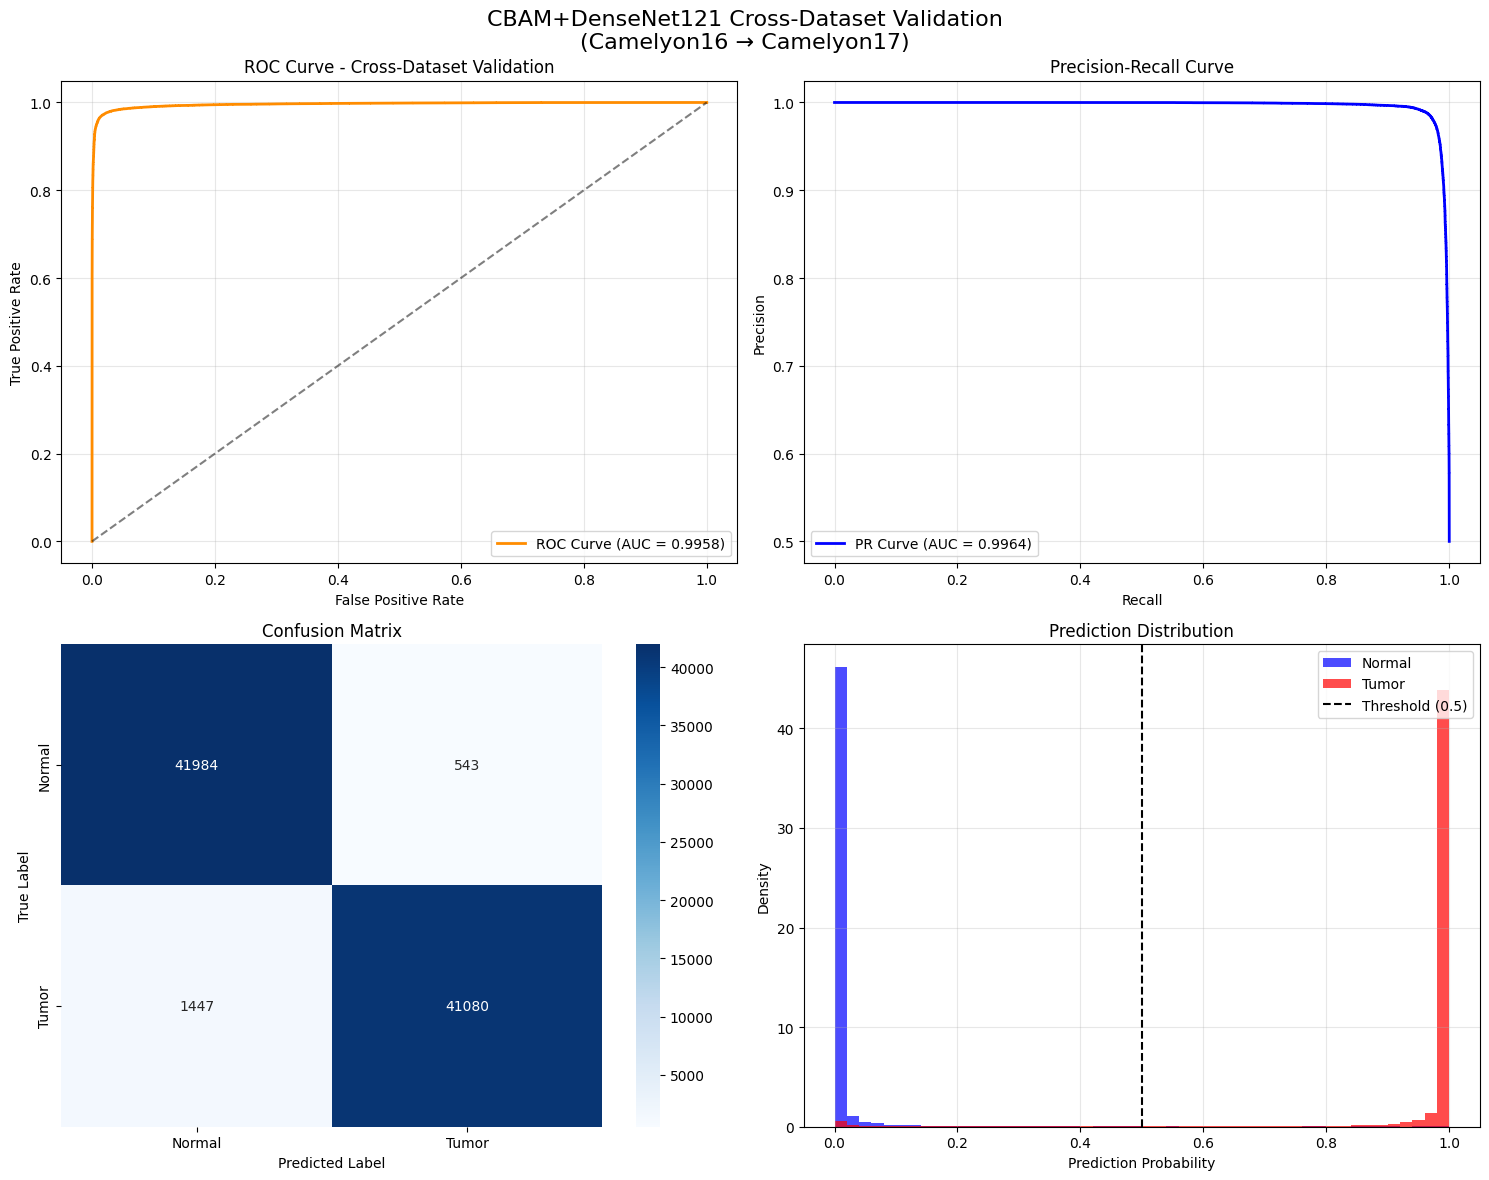

✅ Plots saved to: cbam_densenet_cross_validation_plots.png


In [17]:
# =============================================================================
# VISUALIZATION
# =============================================================================

plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. ROC Curve
fpr, tpr, _ = roc_curve(labels, probs)
axes[0,0].plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})', linewidth=2, color='darkorange')
axes[0,0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0,0].set_xlabel('False Positive Rate')
axes[0,0].set_ylabel('True Positive Rate')
axes[0,0].set_title('ROC Curve - Cross-Dataset Validation')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Precision-Recall Curve
precision_curve, recall_curve, _ = precision_recall_curve(labels, probs)
axes[0,1].plot(recall_curve, precision_curve, label=f'PR Curve (AUC = {pr_auc:.4f})', linewidth=2, color='blue')
axes[0,1].set_xlabel('Recall')
axes[0,1].set_ylabel('Precision')
axes[0,1].set_title('Precision-Recall Curve')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[1,0])
axes[1,0].set_title('Confusion Matrix')
axes[1,0].set_ylabel('True Label')
axes[1,0].set_xlabel('Predicted Label')

# 4. Prediction Distribution
axes[1,1].hist(probs[labels == 0], bins=50, alpha=0.7, label='Normal', color='blue', density=True)
axes[1,1].hist(probs[labels == 1], bins=50, alpha=0.7, label='Tumor', color='red', density=True)
axes[1,1].axvline(decision_threshold, color='black', linestyle='--', label=f'Threshold ({decision_threshold})')
axes[1,1].set_xlabel('Prediction Probability')
axes[1,1].set_ylabel('Density')
axes[1,1].set_title('Prediction Distribution')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('CBAM+DenseNet121 Cross-Dataset Validation\n(Camelyon16 → Camelyon17)', fontsize=16)
plt.tight_layout()
plt.savefig('cbam_densenet_cross_validation_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Plots saved to: cbam_densenet_cross_validation_plots.png")

In [18]:
# =============================================================================
# FINAL SUMMARY
# =============================================================================

print(f"\n{'='*80}")
print("CROSS-DATASET VALIDATION SUMMARY")
print(f"{'='*80}")
print(f"Model Architecture    : CBAM + DenseNet121")
print(f"Training Dataset      : PatchCamelyon (Camelyon16)")
print(f"Test Dataset          : Camelyon17-WILDS (centers 2-4 only)")
print(f"Test Samples          : {len(test_dataset):,}")
print(f"")
print(f"Performance Metrics:")
print(f"  ROC-AUC            : {roc_auc:.4f}")
print(f"  PR-AUC             : {pr_auc:.4f}")
print(f"  Accuracy           : {accuracy:.4f}")
print(f"  F1-Score           : {f1:.4f}")
print(f"  Sensitivity        : {sensitivity:.4f}")
print(f"  Specificity        : {specificity:.4f}")
print(f"")
print(f"Evaluation Time      : {evaluation_time:.1f} seconds")
print(f"{'='*80}")

print("\n🎉 Cross-dataset validation completed successfully!")


CROSS-DATASET VALIDATION SUMMARY
Model Architecture    : CBAM + DenseNet121
Training Dataset      : PatchCamelyon (Camelyon16)
Test Dataset          : Camelyon17-WILDS (centers 2-4 only)
Test Samples          : 85,054

Performance Metrics:
  ROC-AUC            : 0.9958
  PR-AUC             : 0.9964
  Accuracy           : 0.9766
  F1-Score           : 0.9764
  Sensitivity        : 0.9660
  Specificity        : 0.9872

Evaluation Time      : 74.8 seconds

🎉 Cross-dataset validation completed successfully!
